# Boundless DAS: Learning Which Feature Dimensions Matter

Notebooks 04 and 05 trained DAS and DBM on a fixed target (one layer, one token position). Both methods select *which units* to intervene on. But units can be large — the residual stream is 2048-dimensional and a single attention head is 64-dimensional. Within each unit, some dimensions might encode the causal variable while others are unrelated.

**Boundless DAS** (per-feature masking) asks a finer question: *which individual feature dimensions* within each unit encode the causal variable?

The key setting is `tie_masks=False`. In standard DBM, the mask is tied across all dimensions of a unit — the unit is either selected or not. With `tie_masks=False`, each dimension gets its own mask weight, and the learned temperature-annealed sigmoid determines independently whether that dimension is "on" or "off".

In this notebook we:
1. Train Boundless DAS directly on three component types — residual stream, attention heads, and MLPs — using `train_interventions` with `featurizer_kwargs={"tie_masks": False}` to build hands-on intuition
2. Show how the same experiment runs systematically as a (layer × token_position) grid scan via the `subspace` analysis with `method: boundless`

In [1]:
# PARAMETERS
MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"
MAX_NEW_TOKENS = 1

import torch
from causalab.neural.pipeline import LMPipeline
from causalab.tasks.MCQA.causal_models import positional_causal_model
from causalab.tasks.MCQA.counterfactuals import different_symbol
from causalab.methods.filter import filter_dataset
from causalab.neural.activations.site_grids import (
    build_residual_stream_sites,
    build_attention_head_sites,
    build_mlp_sites,
)
from causalab.tasks.MCQA.token_positions import create_token_positions

device = "cuda" if torch.cuda.is_available() else "cpu"

pipeline = LMPipeline(
    MODEL_NAME,
    max_new_tokens=MAX_NEW_TOKENS,
    device=device,
    dtype=torch.bfloat16 if device == "cuda" else torch.float32,
)
pipeline.tokenizer.padding_side = "left"

causal_model = positional_causal_model


def checker(neural_output: dict, causal_output: str) -> bool:
    return (
        causal_output.strip() in neural_output["string"].strip()
        or neural_output["string"].strip() in causal_output.strip()
    )


print(f"Model: {MODEL_NAME}")
print(f"Device: {device}")
print(f"Layers: {pipeline.model.config.num_hidden_layers}")
print(f"Heads per layer: {pipeline.model.config.num_attention_heads}")
print(f"Hidden size: {pipeline.model.config.hidden_size}")

Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


Model: meta-llama/Llama-3.2-1B-Instruct
Device: cuda
Layers: 16
Heads per layer: 32
Hidden size: 2048


## Generating and filtering the dataset

We use `different_symbol` counterfactuals — pairs where the correct answer symbol is swapped to a different letter (e.g., the correct answer moves from label `A` to label `C`). The causal variable is the answer label itself.

We filter both datasets to retain only examples where the model answers both the original and counterfactual correctly. This ensures we are training the mask on signal that the model actually uses, not on examples where the model is already confused.

In [2]:
# PARAMETERS
DATASET_SIZE = 128
FILTER_BATCH_SIZE = 128

print("Generating training dataset...")
train_dataset_raw = [different_symbol() for _ in range(DATASET_SIZE)]

print("Filtering training dataset (keeping pairs the model answers correctly)...")
filtered_train_dataset = filter_dataset(
    dataset=train_dataset_raw,
    pipeline=pipeline,
    causal_model=causal_model,
    metric=checker,
    batch_size=FILTER_BATCH_SIZE,
)

print("\nGenerating test dataset...")
test_dataset_raw = [different_symbol() for _ in range(DATASET_SIZE)]

print("Filtering test dataset...")
filtered_test_dataset = filter_dataset(
    dataset=test_dataset_raw,
    pipeline=pipeline,
    causal_model=causal_model,
    metric=checker,
    batch_size=FILTER_BATCH_SIZE,
)

print(f"\nTrain: {len(filtered_train_dataset)} examples retained (from {DATASET_SIZE})")
print(f"Test:  {len(filtered_test_dataset)} examples retained (from {DATASET_SIZE})")

Generating training dataset...
Filtering training dataset (keeping pairs the model answers correctly)...

Generating test dataset...
Filtering test dataset...

Train: 118 examples retained (from 128)
Test:  105 examples retained (from 128)


## Token positions

`create_token_positions` builds named token positions for MCQA prompts. We select a focused set: the correct answer symbol and the final token (where the model reads out its answer).

For residual stream and MLP targets we pass a list of positions; for attention heads we pass a single position (the last token, where attention output is most predictive).

In [3]:
token_positions_dict = create_token_positions(pipeline)

# PARAMETERS
POSITION_NAMES = [
    "correct_symbol",
    "correct_symbol_period",
    "symbol0",
    "symbol0_period",
    "symbol1",
    "symbol1_period",
    "last_token",
]

token_positions = [token_positions_dict[name] for name in POSITION_NAMES]
last_token_position = token_positions_dict["last_token"]

layers = list(range(pipeline.model.config.num_hidden_layers))
heads = list(range(pipeline.model.config.num_attention_heads))

print(f"Layers: {len(layers)} ({layers[0]}..{layers[-1]})")
print(f"Token positions ({len(token_positions)}): {POSITION_NAMES}")
print(f"Attention head dimension: {pipeline.model.config.hidden_size // pipeline.model.config.num_attention_heads}")

Layers: 16 (0..15)
Token positions (7): ['correct_symbol', 'correct_symbol_period', 'symbol0', 'symbol0_period', 'symbol1', 'symbol1_period', 'last_token']
Attention head dimension: 64


## Training configuration

The critical difference from notebooks 04/05 is `featurizer_kwargs={"tie_masks": False}`.

- `tie_masks=True` (DBM): one learnable mask weight per unit — the entire unit is selected or rejected as a block.
- `tie_masks=False` (Boundless DAS): one learnable mask weight per *feature dimension within each unit* — each of the `k_features` dimensions in the rotation gets its own gate. The result tells you not just which layers and positions encode the variable, but which dimensions within those layers/positions are doing the work.

The `masking` block controls the temperature annealing schedule that hardens the soft sigmoid masks toward binary values over training.

In [4]:
from causalab.methods.trained_subspace.train import train_interventions
from causalab.configs.train_config import merge_with_defaults

# PARAMETERS
TRAIN_BATCH_SIZE = 128
EVAL_BATCH_SIZE = 64
TRAINING_EPOCH = 6
INIT_LR = 0.001
REGULARIZATION_COEFFICIENT = 0.0001

# N_FEATURES controls the rotation dimension for each component type
N_FEATURES_RESIDUAL = 2048   # matches residual stream dimension (hidden_size)
N_FEATURES_ATTN = 64         # matches attention head dimension (hidden_size / num_heads)
N_FEATURES_MLP = 2048        # matches MLP output dimension

base_config = {
    "intervention_type": "mask",
    "featurizer_kwargs": {"tie_masks": False},  # <-- this is what makes it Boundless DAS
    "train_batch_size": TRAIN_BATCH_SIZE,
    "evaluation_batch_size": EVAL_BATCH_SIZE,
    "training_epoch": TRAINING_EPOCH,
    "init_lr": INIT_LR,
    "masking": {
        "regularization_coefficient": REGULARIZATION_COEFFICIENT,
        "temperature_annealing_fraction": 0.5,
        "temperature_schedule": (1.0, 0.001),
    },
}

print("Base config:")
print(f"  intervention_type:           {base_config['intervention_type']}")
print(f"  tie_masks:                   {base_config['featurizer_kwargs']['tie_masks']}")
print(f"  training_epoch:              {TRAINING_EPOCH}")
print(f"  init_lr:                     {INIT_LR}")
print(f"  regularization_coefficient:  {REGULARIZATION_COEFFICIENT}")

Base config:
  intervention_type:           mask
  tie_masks:                   False
  training_epoch:              6
  init_lr:                     0.001
  regularization_coefficient:  0.0001


Each Boundless DAS run below is followed by a `display_feature_counts(...)` call that saves a feature-count heatmap (the headline visualization for `tie_masks=False`) under `artifacts/MCQA/llama32_1b_instruct/subspace_exploration/boundless_k{N}/{component}/heatmaps/` and renders it inline.

In [5]:
import os
from IPython.display import Image, display
from causalab.io.plots.feature_masks import plot_feature_counts
from causalab.io.plots.grid_cells import cells_from_site_grid

# Resolve project root from notebook location.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
EXPLORATION_ROOT = os.path.join(
    PROJECT_ROOT, "artifacts", "MCQA", "llama32_1b_instruct", "subspace_exploration",
)


def display_feature_counts(result, grid, component_name: str, n_features: int) -> None:
    """Save and display the Boundless DAS feature-count heatmap for one component.

    Aggregates `feature_indices` (keyed by opaque `spec.key`) across all keys in
    `result["results_by_key"]` and joins each key's (component, layer,
    head/position) structurally from the grid's own `SiteSpec`s via
    `cells_from_site_grid` — spec keys are never parsed.
    """
    out_dir = os.path.join(
        EXPLORATION_ROOT, f"boundless_k{n_features}", component_name, "heatmaps",
    )
    os.makedirs(out_dir, exist_ok=True)
    save_path = os.path.join(out_dir, "feature_counts.png")

    feature_indices = {}
    for r in result["results_by_key"].values():
        feature_indices.update(r.get("feature_indices") or {})

    if not feature_indices:
        print("No feature_indices in result; nothing to plot.")
        return

    component_type, cells = cells_from_site_grid(grid, feature_indices, n_features)
    plot_feature_counts(
        component_type,
        cells,
        scores=float(result.get("avg_test_score", 0.0)),
        title=f"Boundless DAS feature counts: {component_name}",
        save_path=save_path,
        figure_format="png",
    )
    print(f"\nFeature-count heatmap saved to {save_path}")
    display(Image(filename=save_path))


## 1. Residual stream — one model per layer

`build_residual_stream_sites` with `mode="one_target_per_layer"` groups all token positions within each layer into a single joint group of `SiteSpec`s. We then call `train_interventions` once with the per-layer grid; it trains one model per key and returns per-key scores.

This reveals how well the causal variable can be recovered from each layer's residual stream, across all token positions simultaneously.

Residual stream targets: 16 (one per layer)
  Keys: [(0,), (1,), (2,), (3,)] ...



Residual stream results (per layer):
  Layer  0:  train=1.000  test=1.000
  Layer  1:  train=1.000  test=0.990
  Layer  2:  train=1.000  test=1.000
  Layer  3:  train=1.000  test=0.981
  Layer  4:  train=0.992  test=0.962
  Layer  5:  train=0.992  test=0.952
  Layer  6:  train=0.992  test=0.933
  Layer  7:  train=1.000  test=0.905
  Layer  8:  train=0.983  test=0.876
  Layer  9:  train=0.966  test=0.857
  Layer 10:  train=0.983  test=0.905
  Layer 11:  train=0.992  test=0.952
  Layer 12:  train=0.966  test=0.962
  Layer 13:  train=0.983  test=0.905
  Layer 14:  train=1.000  test=1.000
  Layer 15:  train=1.000  test=1.000

Average test score: 0.949
Best layer:         0  (test=1.000)


causalab/io/plots/utils.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


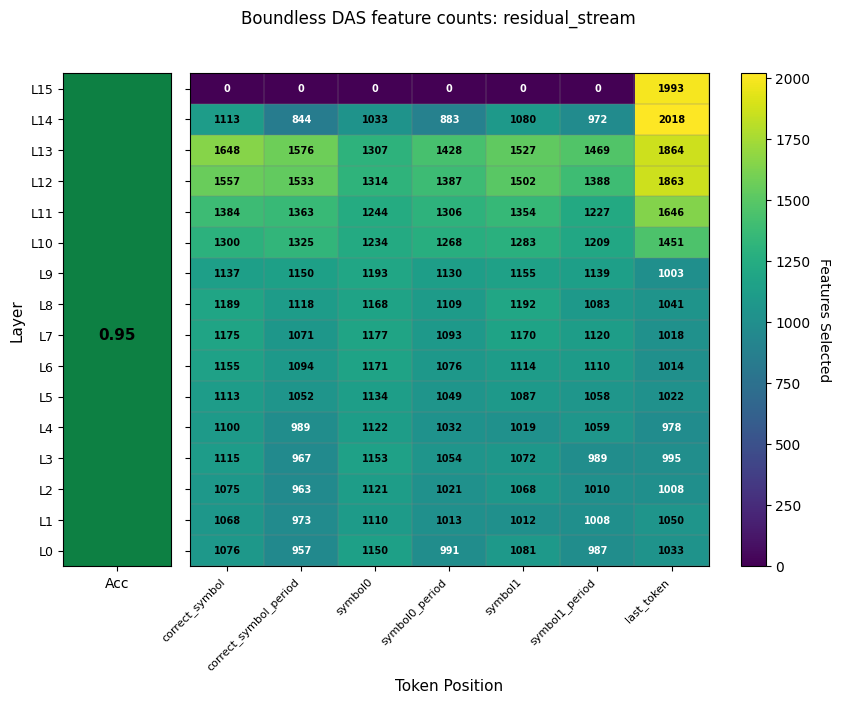


Feature-count heatmap saved to artifacts/MCQA/llama32_1b_instruct/subspace_exploration/boundless_k2048/residual_stream/heatmaps/feature_counts.png


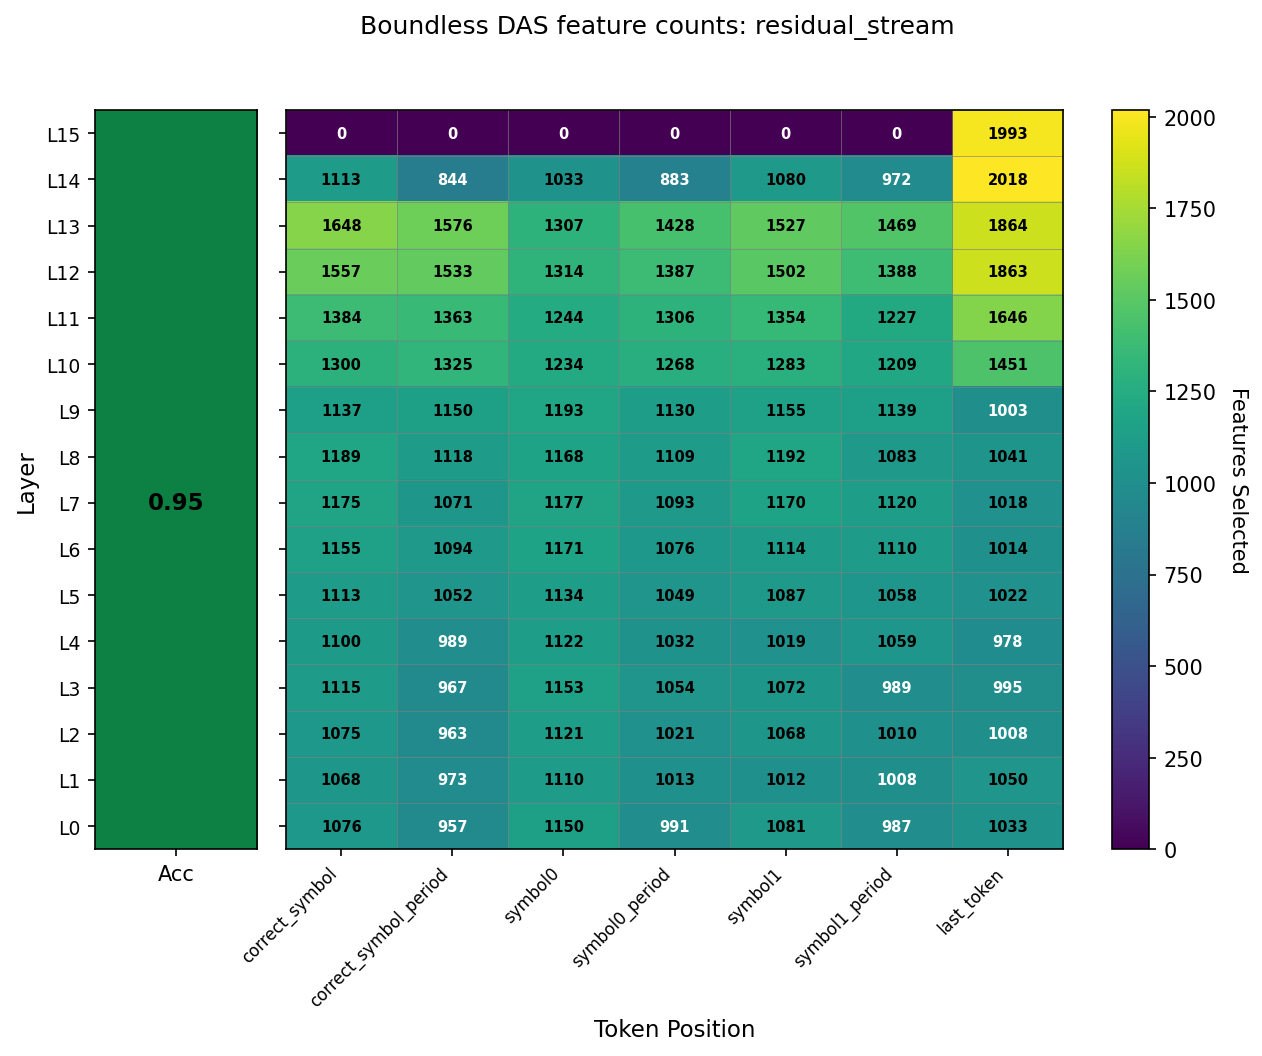

In [6]:
residual_targets = build_residual_stream_sites(
    pipeline=pipeline,
    layers=layers,
    token_positions=token_positions,
    mode="one_target_per_layer",
)

print(f"Residual stream targets: {len(residual_targets)} (one per layer)")
print(f"  Keys: {sorted(residual_targets.keys())[:4]} ...")

residual_config = merge_with_defaults({
    **base_config,
    "DAS": {"n_features": N_FEATURES_RESIDUAL},
    "log_dir": "logs/boundless_residual",
})

residual_result = train_interventions(
    causal_model=causal_model,
    grid=residual_targets,
    train_dataset=filtered_train_dataset,
    test_dataset=filtered_test_dataset,
    pipeline=pipeline,
    target_variable_group=("raw_output",),
    metric=checker,
    config=residual_config,
)

print("\nResidual stream results (per layer):")
for key in sorted(residual_result["results_by_key"].keys()):
    r = residual_result["results_by_key"][key]
    print(f"  Layer {key[0]:>2d}:  train={r['train_score']:.3f}  test={r['test_score']:.3f}")
print(f"\nAverage test score: {residual_result['avg_test_score']:.3f}")
best_key = max(residual_result["results_by_key"], key=lambda k: residual_result["results_by_key"][k]["test_score"])
print(f"Best layer:         {best_key[0]}  (test={residual_result['results_by_key'][best_key]['test_score']:.3f})")

# Save and display the per-unit feature-count heatmap (one row per layer).
display_feature_counts(residual_result, residual_targets, component_name="residual_stream", n_features=N_FEATURES_RESIDUAL)


## 2. Attention heads — single model over all heads

`build_attention_head_sites` with `mode="one_target_all_units"` packs all attention heads across all layers into a single joint group of `SiteSpec`s. A single Boundless DAS model is trained on this combined group.

Each head contributes `N_FEATURES_ATTN` dimensions (the head dimension = hidden_size / num_heads). The per-dimension masks reveal which individual dimensions within which heads encode the answer variable.

Attention target covers 16 layers × 32 heads
  n_features per head: 64  (= hidden_size / num_heads)



Attention heads results:
  train_score: 0.992
  test_score:  0.971


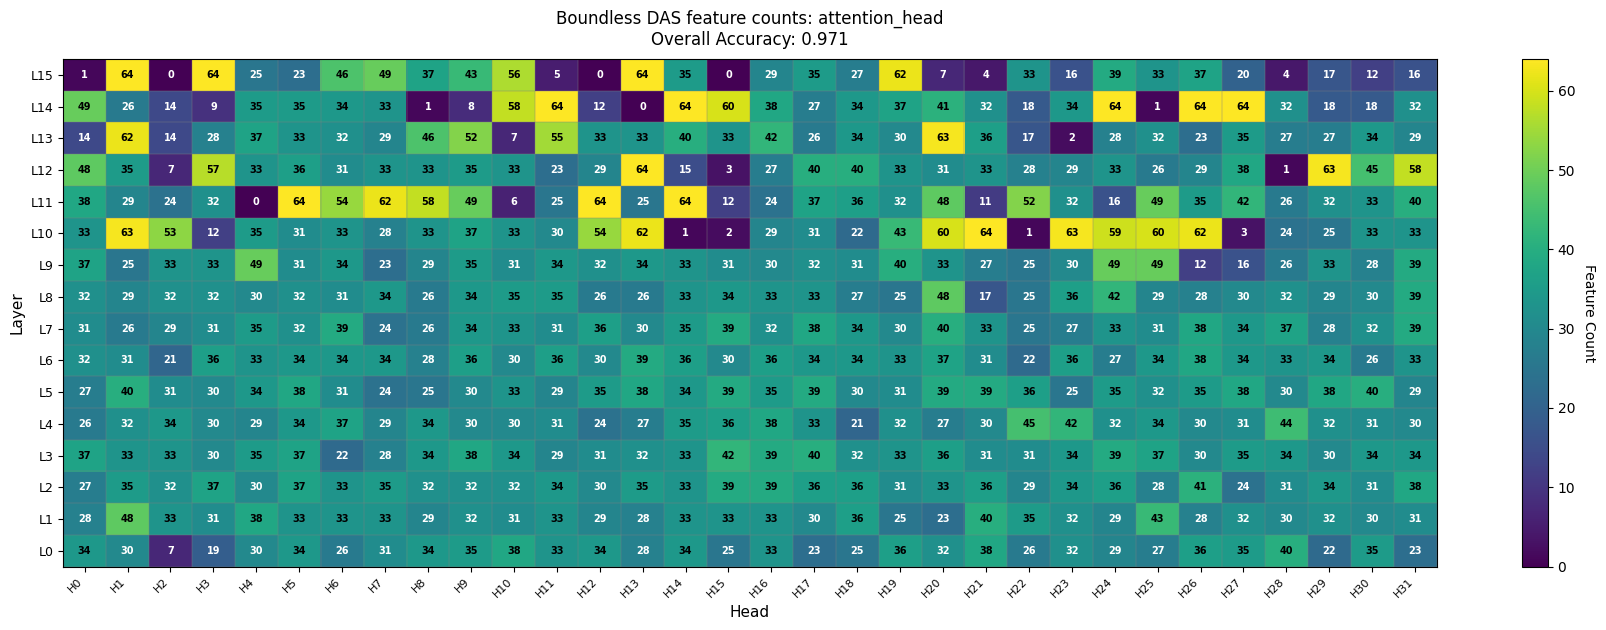


Feature-count heatmap saved to artifacts/MCQA/llama32_1b_instruct/subspace_exploration/boundless_k64/attention_head/heatmaps/feature_counts.png


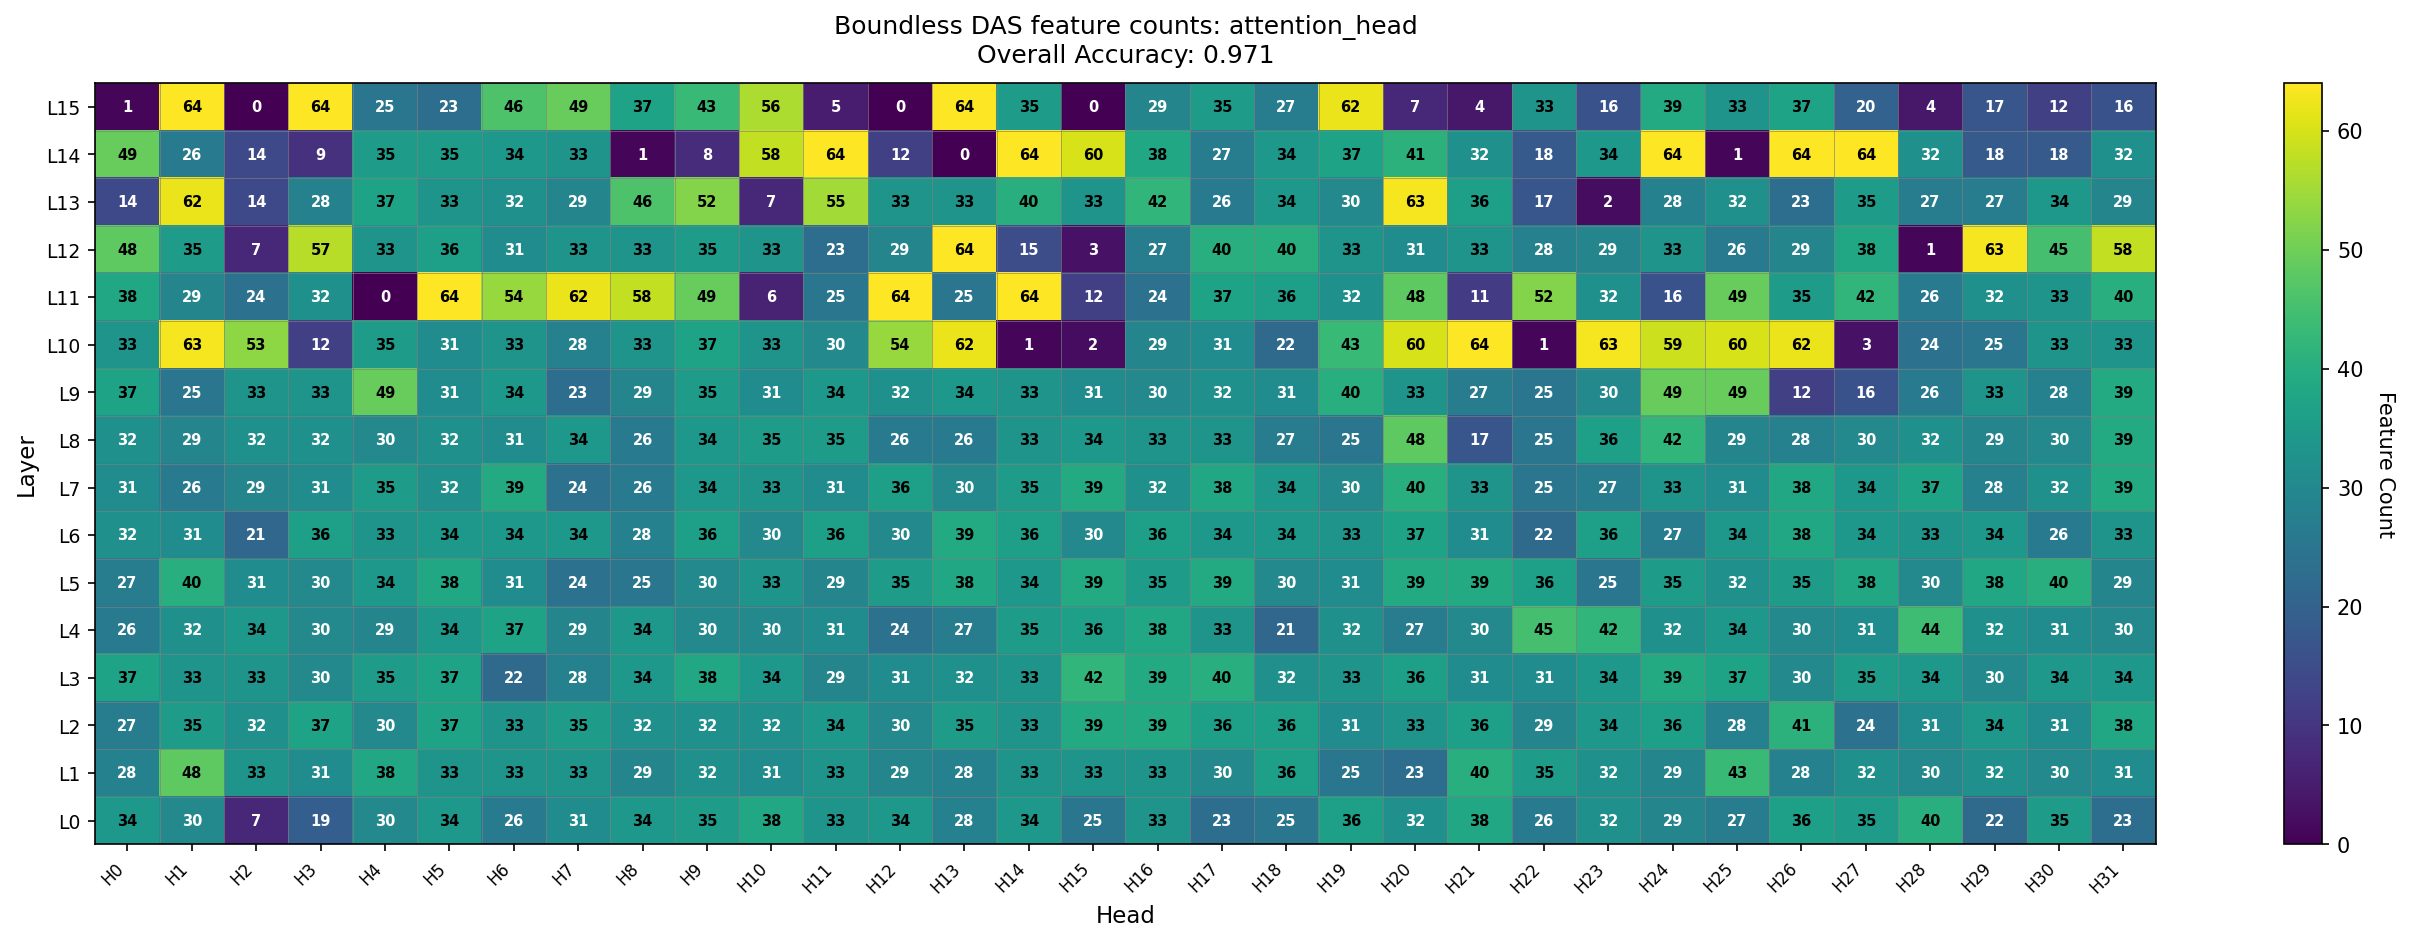

In [7]:
attention_targets = build_attention_head_sites(
    pipeline=pipeline,
    layers=layers,
    heads=heads,
    token_position=last_token_position,
    mode="one_target_all_units",
)

attention_target = attention_targets[("all",)]
print(f"Attention target covers {len(layers)} layers × {len(heads)} heads")
print(f"  n_features per head: {N_FEATURES_ATTN}  (= hidden_size / num_heads)")

attention_config = merge_with_defaults({
    **base_config,
    "DAS": {"n_features": N_FEATURES_ATTN},
    "log_dir": "logs/boundless_attention",
})

attention_result = train_interventions(
    causal_model=causal_model,
    grid={"all": attention_target},
    train_dataset=filtered_train_dataset,
    test_dataset=filtered_test_dataset,
    pipeline=pipeline,
    target_variable_group=("raw_output",),
    metric=checker,
    config=attention_config,
)

attn_r = attention_result["results_by_key"]["all"]
print("\nAttention heads results:")
print(f"  train_score: {attn_r['train_score']:.3f}")
print(f"  test_score:  {attn_r['test_score']:.3f}")

# Save and display the (layer x head) feature-count heatmap.
display_feature_counts(attention_result, attention_targets, component_name="attention_head", n_features=N_FEATURES_ATTN)


## 3. MLPs — single model over all MLPs

`build_mlp_sites` with `mode="one_target_all_units"` groups all MLP outputs across all layers and token positions into a single joint group. We set `n_features` to match the MLP output dimension (same as the residual stream for this model architecture).

MLP target covers 16 layers × 7 token positions
  n_features: 2048  (= MLP output / hidden_size)



MLP results:
  train_score: 0.975
  test_score:  0.895


causalab/io/plots/utils.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


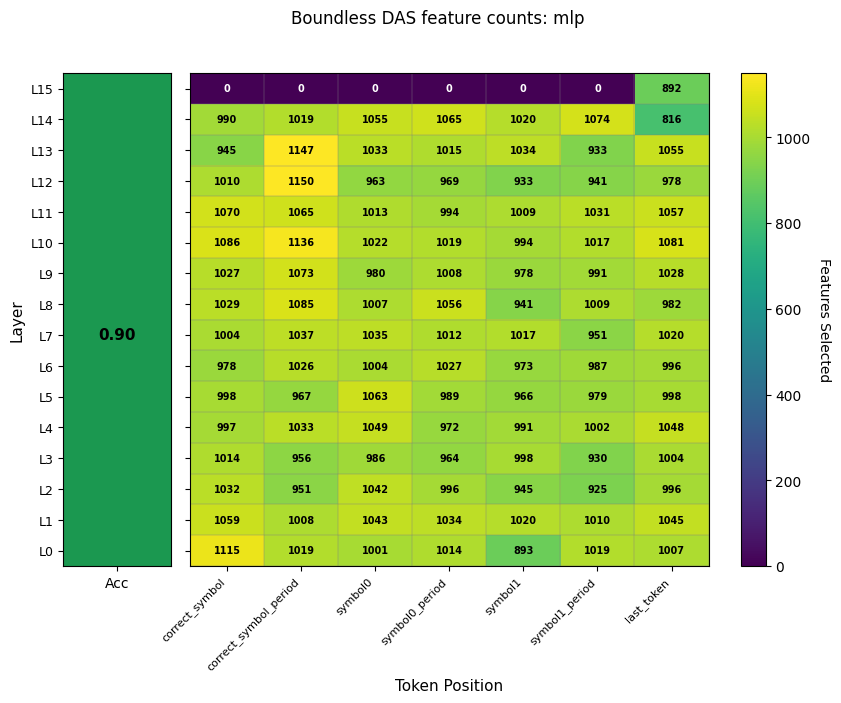


Feature-count heatmap saved to artifacts/MCQA/llama32_1b_instruct/subspace_exploration/boundless_k2048/mlp/heatmaps/feature_counts.png


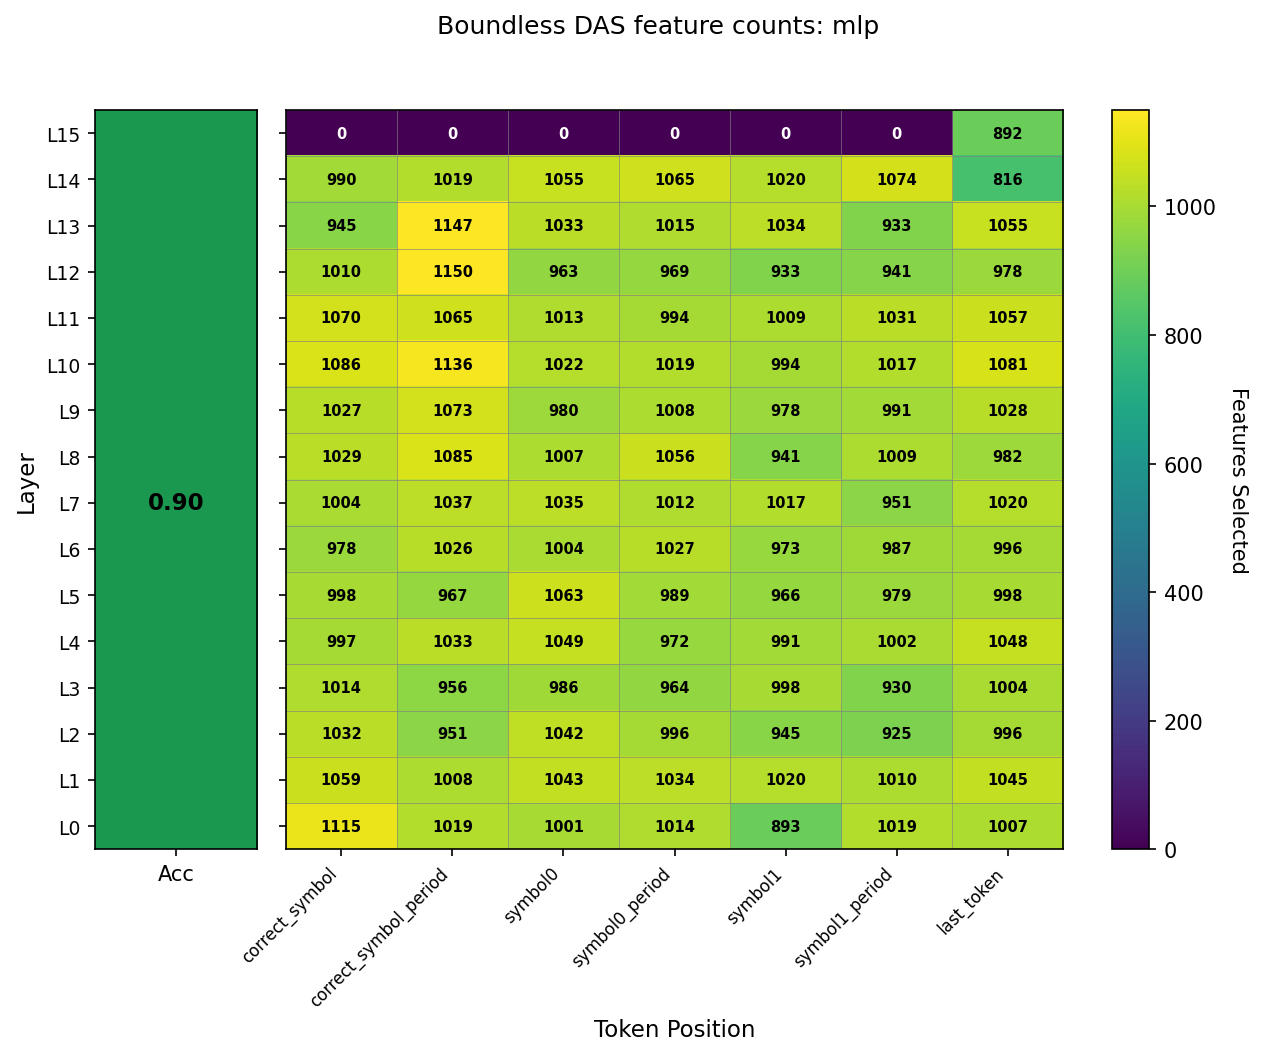

In [8]:
mlp_targets = build_mlp_sites(
    pipeline=pipeline,
    layers=layers,
    token_positions=token_positions,
    mode="one_target_all_units",
)

mlp_target = mlp_targets[("all",)]
print(f"MLP target covers {len(layers)} layers × {len(token_positions)} token positions")
print(f"  n_features: {N_FEATURES_MLP}  (= MLP output / hidden_size)")

mlp_config = merge_with_defaults({
    **base_config,
    "DAS": {"n_features": N_FEATURES_MLP},
    "log_dir": "logs/boundless_mlp",
})

mlp_result = train_interventions(
    causal_model=causal_model,
    grid={"all": mlp_target},
    train_dataset=filtered_train_dataset,
    test_dataset=filtered_test_dataset,
    pipeline=pipeline,
    target_variable_group=("raw_output",),
    metric=checker,
    config=mlp_config,
)

mlp_r = mlp_result["results_by_key"]["all"]
print("\nMLP results:")
print(f"  train_score: {mlp_r['train_score']:.3f}")
print(f"  test_score:  {mlp_r['test_score']:.3f}")

# Save and display the (layer x token_position) feature-count heatmap.
display_feature_counts(mlp_result, mlp_targets, component_name="mlp", n_features=N_FEATURES_MLP)


## Summary across component types

In [9]:
print("=" * 60)
print("Boundless DAS — test scores by component")
print("=" * 60)

best_residual_key = max(
    residual_result["results_by_key"],
    key=lambda k: residual_result["results_by_key"][k]["test_score"],
)
best_residual_r = residual_result["results_by_key"][best_residual_key]

print(f"\nResidual stream (per-layer, best layer {best_residual_key[0]}):")
print(f"  best test score:  {best_residual_r['test_score']:.3f}")
print(f"  avg  test score:  {residual_result['avg_test_score']:.3f}")

print("\nAttention heads (all heads, last_token):")
print(f"  test score:       {attn_r['test_score']:.3f}")

print("\nMLPs (all MLPs, all positions):")
print(f"  test score:       {mlp_r['test_score']:.3f}")

all_scores = {
    f"Residual stream layer {best_residual_key[0]}": best_residual_r["test_score"],
    "Attention heads": attn_r["test_score"],
    "MLPs": mlp_r["test_score"],
}
winner = max(all_scores, key=all_scores.get)
print(f"\nBest component: {winner} ({all_scores[winner]:.3f})")

Boundless DAS — test scores by component

Residual stream (per-layer, best layer 0):
  best test score:  1.000
  avg  test score:  0.949

Attention heads (all heads, last_token):
  test score:       0.971

MLPs (all MLPs, all positions):
  test score:       0.895

Best component: Residual stream layer 0 (1.000)


## What to look for

**Test scores** tell you how well the learned per-feature mask recovers the causal variable after training. A score near 1.0 means the mask successfully identified the key dimensions and the causal information is recoverable. Lower scores can mean:
- The component genuinely encodes less of this variable (expected for some layers / components)
- The training didn't converge — try increasing `TRAINING_EPOCH` or lowering `REGULARIZATION_COEFFICIENT`
- The dataset is too small — the mask is overfitting and not generalizing

**Comparing component types:**
- The residual stream per-layer scan shows which layers are most information-rich, and usually has a sharp peak around the layer where `locate` placed the variable
- Attention heads on the last token tend to score well because that is where the model reads out the answer; the score captures how the answer symbol is routed through attention
- MLPs often score similarly to the residual stream because the MLP output is summed back into the residual stream — the variable is present in both

**Compared to DBM (`tie_masks=True`):** Boundless DAS gives the same localization signal at the unit level, but additionally tells you *how many dimensions* within each unit carry the variable. If the mask activates only a handful of dimensions out of 2048, the representation is geometrically sparse — a useful prior for downstream analyses like `activation_manifold`.

Rerun the cells above with different `TRAINING_EPOCH`, `REGULARIZATION_COEFFICIENT`, or a different subset of `POSITION_NAMES` to explore the sensitivity of the result.

---

## From exploration to analysis

The three component-wise training runs above answer questions about ad-hoc targets you assembled by hand. A research question lives at the level of populations: **across all (layer, token_position) cells in the residual stream, which sites encode the causal variable, and how many feature dimensions per cell does the representation actually use?**

Answering that at scale requires:

- Running the same `train_interventions` call across a systematic (layer × token_position) grid
- Aggregating test scores into a per-cell heatmap to identify the best localization sites
- Saving trained models and grid results for downstream analyses (`activation_manifold`, `path_steering`)
- Reproducible configuration under version control

This is exactly what the **`subspace` analysis** does with `method: boundless`. Under the hood it calls `run_boundless_grid()`, which calls the same `train_interventions` you just wrote — with `intervention_type="mask"` and `tie_masks=False` — across every cell in the grid, then saves `grid_results.json` and per-cell heatmaps.

The `subspace` analysis supports four methods:
- `pca` — finds the top variance directions (no training, purely geometric)
- `das` — learns a tied linear subspace (one rotation, no per-feature masks)
- `dbm` — learns per-unit binary masks (`tie_masks=True`)
- `boundless` — learns per-feature masks (`tie_masks=False`, configured through the `boundless:` block)

Section 2 uses `method: boundless` to run the population-level grid scan.

## Running `subspace` with `method: boundless` end-to-end

The runner expresses the same three-component sweep as Section 1 — residual stream, attention heads, MLPs — through a single `subspace` analysis with a `modes:` list. Each mode entry overrides the analysis defaults (component type, layers, token positions, optional per-mode `k_features`) and writes its artifacts to a per-mode subdirectory. The runner config keeps the standard `- analysis/subspace` defaults entry; the iteration happens inside the analysis layer.

| Field | What it controls |
|---|---|
| `method` | `pca`, `das`, `dbm`, or `boundless` (per-feature masks) |
| `k_features` | Rotation dimension at the analysis level; per-mode overrides allowed |
| `modes` | List of component sweeps; each entry overrides `component_type`, `layers`, etc. |
| `boundless.training_epoch` / `boundless.lr` / `boundless.regularization_coefficient` | Mask-optimizer hyperparameters |
| `visualization.figure_format` | `png` for inline notebook display |


In [ ]:
config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: MCQA
  - /model: llama32_1b_instruct
  - /analysis/subspace
  - _self_
task:
  enumerate_all: true  # use all possible MCQA inputs
  target_variable: answer

subspace:
  method: boundless
  k_features: 64
  batch_size: 32
  visualization:
    figure_format: png
  boundless:
    training_epoch: 5
    lr: 0.001
    regularization_coefficient: 0.1
  # Three component sweeps — each writes to subspace/boundless_k64/{name}/answer/.
  modes:
    - name: residual_stream
      component_type: residual_stream
      layers: [0, 4, 8, 12, 15]
      token_positions: ["correct_symbol", "last_token"]
    - name: attention_head
      component_type: attention_head
      layers: [0, 4, 8, 12, 15]
      heads: null            # null = all heads in each layer
      token_position: last_token
    - name: mlp
      component_type: mlp
      layers: [0, 4, 8, 12, 15]
      token_positions: ["correct_symbol", "last_token"]
"""


In [11]:
from omegaconf import OmegaConf
from causalab.io.configs import save_runner_config, load_runner_config

path = save_runner_config(config_yaml, "boundless_das_demo")
print(f"Written to {path}\n")

cfg = load_runner_config("boundless_das_demo")
print("Full hydra config:")
print(OmegaConf.to_yaml(cfg))

Written to causalab/configs/boundless_das_demo.yaml

Full hydra config:
seed: 42
experiment_root: artifacts/${task.name}/${model.id}
slurm:
  time: 04:00:00
task:
  name: MCQA
  intervention_metric: string_match
  max_new_tokens: 1
  colormap: viridis
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  target_variable: answer
model:
  id: llama32_1b_instruct
  name: meta-llama/Llama-3.2-1B-Instruct
  device: auto
  dtype: bfloat16
  slurm:
    gpus: 1
subspace:
  _name_: subspace
  _subdir: ${.method}_k${.k_features}
  _output_dir: ${experiment_root}/subspace/${._subdir}
  method: boundless
  k_features: 64
  batch_size: 32
  component_type: residual_stream
  layers: null
  token_positions:
  - last_token
  heads: null
  token_position: null
  modes:
  - name: residual_stream
    component_type: residual_stream
    layers:
    - 0
    - 4
    - 8
    - 12
    - 15
    token_positions:
    - correct_symbol
    - last_token
  - name: attention_

Run the analysis via `scripts/run_exp.sh`. This is the same entry point used from the command line — the return code check makes failures visible as Python exceptions.

In [ ]:
import os
import subprocess
import causalab

project_root = os.path.dirname(os.path.dirname(causalab.__file__))

rc = subprocess.run(
    ["bash", "scripts/run_exp.sh", "boundless_das_demo"],
    cwd=project_root,
)
if rc.returncode != 0:
    raise Exception(f"Experiment failed with return code {rc.returncode}")

[2026-05-05 14:27:55,253][__main__][INFO] - === Step: subspace (subspace) ===
[2026-05-05 14:28:06,611][__main__][INFO] - Running analysis: subspace | target_variable: answer
[2026-05-05 14:28:06,615][__main__][INFO] - Resolved config:
seed: 42
experiment_root: artifacts/${task.name}/${model.id}
slurm:
  time: 04:00:00
task:
  name: MCQA
  intervention_metric: string_match
  max_new_tokens: 1
  colormap: viridis
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  target_variable: answer
model:
  id: llama32_1b_instruct
  name: meta-llama/Llama-3.2-1B-Instruct
  device: auto
  dtype: bfloat16
  slurm:
    gpus: 1
subspace:
  _name_: subspace
  _subdir: ${.method}_k${.k_features}
  _output_dir: ${experiment_root}/subspace/${._subdir}
  method: boundless
  k_features: 64
  batch_size: 32
  component_type: residual_stream
  layers: null
  token_positions:
  - last_token
  heads: null
  token_position: null
  modes:
  - name: residual_stream
    c

Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


[2026-05-05 14:28:08,074][huggingface_hub.file_download][ERROR] - Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'
[2026-05-05 14:28:08,610][causalab.analyses.subspace.main][INFO] - === subspace mode: residual_stream (component_type=residual_stream) ===


Training InterchangeTarget(1 groups, 1 total units)...:   0%|          | 0/20 [00:00<?, ?it/s]
Epoch: 0:  97%|█████████▋| 31/32 [00:02<00:00, 14.93it/s, loss=1.83, accuracy=0.43, token_accuracy=0.43]
Training InterchangeTarget(1 groups, 1 total units)...:   5%|▌         | 1/20 [00:02<00:54,  2.89s/it, loss=1.8305, accuracy=0.4294, token_accuracy=0.4294]
Epoch: 1: 100%|██████████| 32/32 [00:01<00:00, 21.95it/s, loss=1.65, accuracy=0.57, token_accuracy=0.57]
Training InterchangeTarget(1 groups, 1 total units)...:  10%|█         | 2/20 [00:04<00:37,  2.06s/it, loss=1.6491, accuracy=0.4973, token_accuracy=0.4973]
Epoch: 2: 100%|██████████| 32/32 [00:01<00:00, 21.88it/s, loss=1.39, accuracy=0.57, token_accuracy=0.57]
Training InterchangeTarget(1 groups, 1 total units)...:  15%|█▌        | 3/20 [00:05<00:30,  1.79s/it, loss=1.3873, accuracy=0.5716, token_accuracy=0.5716]
Epoch: 3: 100%|██████████| 32/32 [00:01<00:00, 21.98it/s, loss=1.12, accuracy=1, token_accuracy=1]
Training InterchangeTar

[2026-05-05 14:33:07,279][causalab.analyses.subspace.grid][INFO] - Boundless DAS grid complete. Avg train=0.404, avg test=0.394
[2026-05-05 14:33:07,784][causalab.analyses.subspace.main][INFO] - Grid best cell: (layer=0, position=correct_symbol) score=0.9800


causalab/io/plots/utils.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[2026-05-05 14:33:08,208][causalab.analyses.subspace.main][INFO] - === subspace mode: attention_head (component_type=attention_head) ===


Training InterchangeTarget(1 groups, 160 total units)...:   0%|          | 0/20 [00:00<?, ?it/s]
Epoch: 0: 100%|██████████| 32/32 [00:49<00:00,  1.27s/it, loss=7.91, accuracy=0, token_accuracy=0]
Training InterchangeTarget(1 groups, 160 total units)...:   5%|▌         | 1/20 [00:49<15:42, 49.58s/it, loss=7.9122, accuracy=0.0029, token_accuracy=0.0029]
Epoch: 1: 100%|██████████| 32/32 [00:49<00:00,  1.26s/it, loss=7.84, accuracy=0, token_accuracy=0]
Training InterchangeTarget(1 groups, 160 total units)...:  10%|█         | 2/20 [01:39<14:53, 49.65s/it, loss=7.8437, accuracy=0.0029, token_accuracy=0.0029]
Epoch: 2: 100%|██████████| 32/32 [00:49<00:00,  1.26s/it, loss=7.78, accuracy=0, token_accuracy=0]
Training InterchangeTarget(1 groups, 160 total units)...:  15%|█▌        | 3/20 [02:28<14:04, 49.65s/it, loss=7.7791, accuracy=0.0029, token_accuracy=0.0029]
Epoch: 3: 100%|██████████| 32/32 [00:49<00:00,  1.27s/it, loss=7.6, accuracy=0, token_accuracy=0]
Training InterchangeTarget(1 group

## Artifacts

Outputs land in `artifacts/{task}/{model}/subspace/{method}_k{k_features}/{mode_name}/{target_variable}/`. With three modes, you get three sibling subdirectories — `residual_stream/`, `attention_head/`, `mlp/` — each containing its own `grid_results.json`, `metadata.json`, and `heatmaps/`.

In [ ]:
# Walk over the configured modes and resolve each mode's artifact dir.
subspace_root = os.path.join(
    project_root,
    cfg.experiment_root,
    "subspace",
    cfg.subspace._subdir,
)
modes = list(cfg.subspace.modes) if cfg.subspace.get("modes") else [
    {"name": cfg.subspace.get("component_type", "residual_stream")}
]
mode_dirs = {}
for mode in modes:
    mode_name = mode["name"] if "name" in mode else mode["component_type"]
    mode_dir = os.path.join(subspace_root, mode_name, cfg.task.target_variable)
    mode_dirs[mode_name] = mode_dir
    print(f"{mode_name:>16s}: {mode_dir}")
    if os.path.isdir(mode_dir):
        print(f"{'':>16s}  contents: {sorted(os.listdir(mode_dir))}")


### Per-mode results

For each mode, we display the headline `feature_counts.png` (always saved for the `boundless` method) and, where applicable, the residual-stream score heatmaps (`train.png` and `test.png`, saved only when `component_type == residual_stream`). The feature-count heatmap is the Boundless-DAS-specific view: each cell shows how many of the unit's `k_features` dimensions the mask kept active.

In [ ]:
import json

for mode_name, mode_dir in mode_dirs.items():
    print("=" * 72)
    print(f"Mode: {mode_name}")
    print("=" * 72)

    grid_path = os.path.join(mode_dir, "grid_results.json")
    if os.path.exists(grid_path):
        with open(grid_path) as f:
            grid_results = json.load(f)
        best = grid_results.get("best_cell")
        if best:
            print(f"  Best cell: layer={best.get('layer')}, position={best.get('token_position')}")
        scores = grid_results.get("scores_per_cell", {})
        if scores:
            print("  Per-cell test scores:")
            for k, v in sorted(scores.items()):
                print(f"    {k:40s}  {float(v):.3f}")

    heatmaps_dir = os.path.join(mode_dir, "heatmaps")
    for name in ("feature_counts", "train", "test"):
        p = os.path.join(heatmaps_dir, f"{name}.png")
        if os.path.exists(p):
            print(f"\n  {name} heatmap → {p}")
            display(Image(filename=p))
    print()


All three modes write the same shape of artifact tree (`grid_results.json`, `metadata.json`, `heatmaps/`). Score heatmaps (`train.png`, `test.png`) are residual-stream-specific; attention-head and MLP modes use `one_target_all_units` and only produce the headline `feature_counts.png`.

## Takeaway

**What a good result looks like, per mode:**
- **Residual stream** — clear localization on the test heatmap (a few cells score   much higher than the rest); train ≈ test; best cell matches the layer identified   by `locate` (if you have already run it).
- **Attention heads** — the feature-count heatmap shows mask sparsity per (layer, head);   a small number of heads with low feature counts suggests fine-grained head specialization.
- **MLPs** — the (layer × token_position) feature-count heatmap shows where the variable   is encoded most sparsely. High counts everywhere suggests the variable is distributed.

**What to try next:**
- Tune `boundless.regularization_coefficient` per mode to push masks sparser.
- Switch a mode to `method: das` (no masks) to compare fine-grained vs. coarse subspace tests.
- Run `activation_manifold` on the residual-stream subspace to see geometric structure.

For the full `subspace` walkthrough including single-cell detailed analysis, scatter plots, and cross-method comparison: `causalab/analyses/subspace/demo.ipynb`.